In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.append('/home/rkievit/masterproject/masterproject/src')
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')

from data_queries import query_extra_data



In [16]:
#plt.style.available
plt.style.use('default')
mpl.rcParams['axes.grid'] = True
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['font.size'] = 11
mpl.rcParams['font.family'] = 'serif'

In [4]:
radius = '1as'
method = 'nearest'

rpath = '../../results/'
dpath = '../../../data/' 
xm_all = np.load(rpath+'crossmatch_1as_all_neighbours.npy')
xm_near = np.load(rpath+'crossmatch_1as_best_neighbour_nearest.npy')
xm_bright = np.load(rpath+'crossmatch_1as_best_neighbour_brightest.npy') 

xm = np.load(rpath+f'crossmatch_{radius}_best_neighbour_{method}.npy')

In [5]:
# Get Gaia data
extra_gdata = ['phot_g_mean_mag', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error']
xm_all, gdata_all = query_extra_data(xm_all, extra_gdata)
xm_near, gdata_near = query_extra_data(xm_near, extra_gdata)
xm_bright, gdata_bright = query_extra_data(xm_bright, extra_gdata)

# Get Hipp data
extra_hdata = ['hp_mag', 'b_v']
xm_all, hdata_all = query_extra_data(xm_all, extra_hdata, cat='hipp')
xm_near, hdata_near = query_extra_data(xm_near, extra_hdata, cat='hipp')
xm_bright, hdata_bright = query_extra_data(xm_bright, extra_hdata, cat='hipp')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
500 Error 500:
esavo.tap.TAPException: Error while uploading table "xm_table" : Can not execute the following SQL: 
CREATE TABLE user_rkievit.xm_table ( "hip" BIGINT, "source_id" BIGINT,  xm_table_oid SERIAL ) TABLESPACE gacs_netapp
Because: ERROR: relation "xm_table" already exists
Table xm_table for rkievit already exists. Trying again with _0..
Sending pytable.
Uploaded table 'xm_table_0'.
INFO: Query finished. [astroquery.utils.tap.core]
Table 'xm_table_0' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.


## Hipparcos Values Matched vs. Unmatched

In [6]:
hipp = fits.open(dpath+'Hipparcos2.fits')[1].data
hip_ids = hipp['hip']

hip_matched = [] # Appending slow but whatever
hip_nomatch = []

for i,hip in enumerate(hip_ids):
    if hip in xm[:,0]:
        hip_matched.append(i)
    else:

        hip_nomatch.append(i)
hip_matched = np.array(hip_matched)
hip_nomatch = np.array(hip_nomatch)

In [7]:

print(f"Number of matched Hipparcos stars: {hip_matched.shape[0]}")
print(f"Number of unmatched Hipparcos stars: {hip_nomatch.shape[0]}")

Number of matched Hipparcos stars: 116901
Number of unmatched Hipparcos stars: 1054


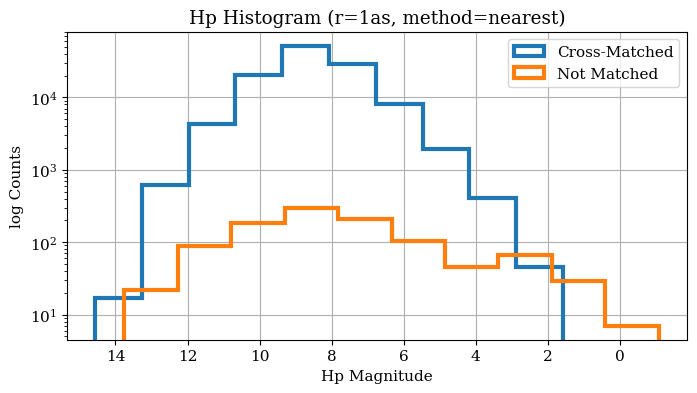

In [14]:
# Compare histograms of magnitude
fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(hipp['hp_mag'][hip_matched], histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(hipp['hp_mag'][hip_nomatch], histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Hp Magnitude')
ax.set_ylabel('log Counts')
ax.set_title(f"Hp Histogram (r={radius}, method={method})")
ax.invert_xaxis()

plt.legend()
plt.show()

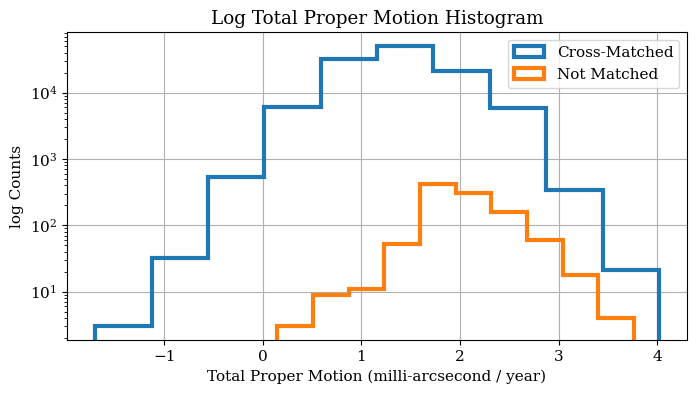

In [19]:
# Compare histogram of proper mitions
pm_matched = np.sqrt((hipp['pm_ra'][hip_matched]**2.) + (hipp['pm_de'][hip_matched]**2))
pm_nomatch = np.sqrt((hipp['pm_ra'][hip_nomatch]**2.) + (hipp['pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(pm_matched), histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Total Proper Motion (milli-arcsecond / year)')
ax.set_ylabel('log Counts')
ax.set_title(f"Log Total Proper Motion Histogram")


plt.legend()
plt.show()

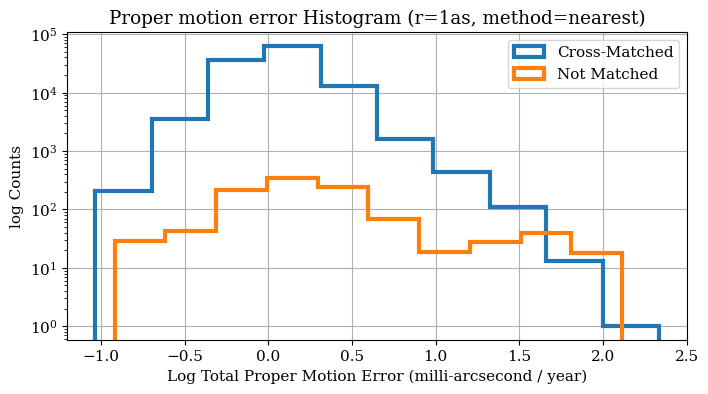

In [23]:
# Compare histogram of proper motion errors
e_pm_matched = np.sqrt((hipp['e_pm_ra'][hip_matched]**2.) + (hipp['e_pm_de'][hip_matched]**2))
e_pm_nomatch = np.sqrt((hipp['e_pm_ra'][hip_nomatch]**2.) + (hipp['e_pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(e_pm_matched),histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(e_pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Log Total Proper Motion Error (milli-arcsecond / year)')

ax.set_ylabel('log Counts')
ax.set_title(f"Proper motion error Histogram (r={radius}, method={method})")

plt.legend()
plt.show()

## Gaia properties of Matched objects

In [11]:
print(extra_gdata)
print(extra_hdata)
hipp_bv = hdata_near[:,1]
hp_mag = hdata_near[:,0]
gaia_g = gdata_near[:,0]

['phot_g_mean_mag', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error']
['hp_mag', 'b_v']


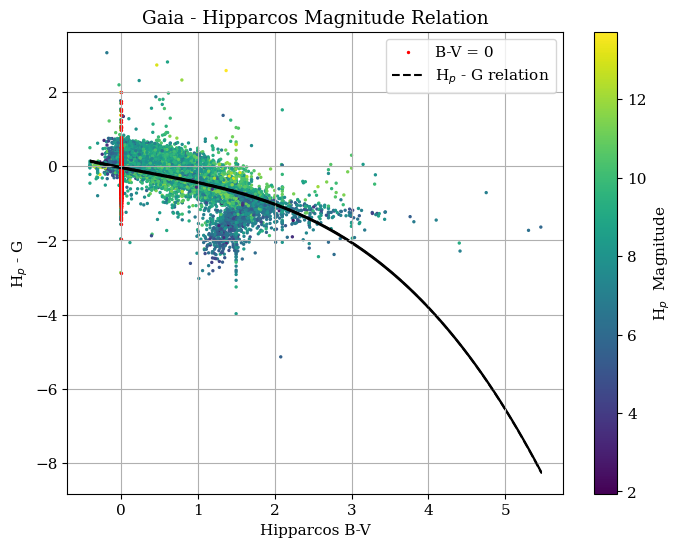

In [42]:
# G - Hp relation reported on the gaia archive doccs
x = np.linspace(np.min(hipp_bv), np.max(hipp_bv), 1000)
y = -0.02392 - 0.4069*x + 0.04569*(x**2) - 0.0452*(x**3)
sigma = 0.02417

fig, ax = plt.subplots(1,1, figsize=(8, 6))
bv0_mask = np.where(hipp_bv==0.)

scatter = ax.scatter(hipp_bv, gaia_g-hp_mag, s=2, c=gaia_g)
ax.scatter(hipp_bv[bv0_mask], (gaia_g-hp_mag)[bv0_mask], s=2, c='red', label='B-V = 0')
ax.plot(x,y,c='black',ls='--', label=f"H$_p$ - G relation")
ax.fill_between(x,y-sigma,y+sigma, color='black')
cb = plt.colorbar(scatter)
cb.set_label(f"H$_p$  Magnitude")

ax.set_ylabel(f"H$_p$ - G")
ax.set_xlabel("Hipparcos B-V")
ax.set_title("Gaia - Hipparcos Magnitude Relation")

plt.legend()
plt.show()

The white line is the assumption we have made for the limit of the magnitude of Gaia objects, this line should perfectly match with the observations if this relation exactly holds. If an object lies above this black line, then Hp - G is bigger, and thus the Gaia star is brighter. If the star is below the line, then the Gaia star is less bright then we had assumed

In [46]:
pos_gaia_params = ['ra', 'dec', 'ra_error', 'dec_error', 'ra_dec_corr']
pos_hipp_params = ['ra', 'dec', 'e_ra_rad', 'e_de_rad', 'u2']
xm = xm_all

xm, pos_gaia = query_extra_data(xm, pos_gaia_params)
xm, pos_hipp = query_extra_data(xm, pos_hipp_params, cat='hipp')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Table 'xm_table' deleted.


In [60]:
gaia_ra_mas = pos_gaia[:,0] * 3600 * 1e3
gaia_de_mas = pos_gaia[:,1] * 3600 * 1e3
hipp_ra_mas = pos_hipp[:,0] * 3600 * 1e3
hipp_de_mas = pos_hipp[:,1] * 3600 * 1e3

In [162]:
# Plot double candidated stars
u, idx, c = np.unique(xm[:, 0], return_counts=True, return_index=True)
doubles = idx[c>1]
#random_idx = np.random.choice(doubles)
random_idx = np.random.choice(idx)
hipp_id = random_idx
gaia_ids = []
for i in range(c[random_idx]):
    gaia_ids.append(random_idx + i)

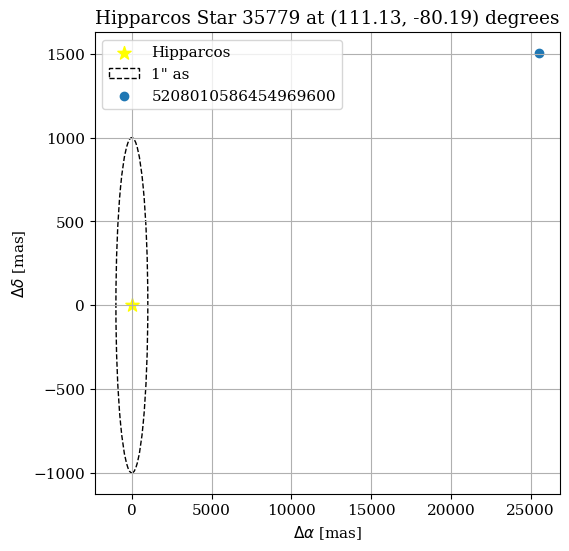

In [176]:
#random_idx = np.random.choice(idx)
#hipp_id = random_idx
#gaia_ids = []
#for i in range(c[random_idx]):
#    gaia_ids.append(random_idx + i)

from matplotlib.patches import Circle, Ellipse
cs_radius = 1
fig, ax = plt.subplots(1,1, figsize=(6,6))

ax.scatter(0, 0, s=100, c='yellow', marker='*',label='Hipparcos')
hipp_err_ellipse = Ellipse((0,0), pos_hipp[:,2][hipp_id], pos_hipp[:,3][hipp_id], fill=False, ec='yellow')
ax.add_patch(hipp_err_ellipse)


conesearch_circle = Circle((0,0), cs_radius * 1e3, fill=False, ec='black', ls='--', label=f'{cs_radius}" as')
ax.add_patch(conesearch_circle)
for gaia_id in gaia_ids:
    ax.scatter(gaia_ra_mas[gaia_id] - hipp_ra_mas[hipp_id], gaia_de_mas[gaia_id] - hipp_de_mas[hipp_id],  label=xm[:,1][gaia_id])
    gaia_err_ellipse = Ellipse((gaia_ra_mas[gaia_id] - hipp_ra_mas[hipp_id],gaia_de_mas[gaia_id] - hipp_de_mas[hipp_id]),
                               pos_gaia[:,2][gaia_id], pos_gaia[:,3][gaia_id], fill=False)
    ax.add_patch(gaia_err_ellipse)

ax.set_xlabel(r"$\Delta\alpha$ [mas]")
ax.set_ylabel(r"$\Delta\delta$ [mas]")
ax.set_title(f"Hipparcos Star {hipp_id} at ({pos_hipp[:,0][hipp_id]:.2f}, {pos_hipp[:,1][hipp_id]:.2f}) degrees")

plt.savefig('../../../figures/example_skyplot_sigma.png', bbox_inches='tight')


plt.legend()
plt.show()